This jupyter notebook describes the implementation of the Metropolis-Hasting Algorithm, which is a realization of the Monte Carlo Markov Chain (MCMC) Method. 

Example: We use the Metropolis - Hasting Algorithm for generating random values of $\sigma^2$ following the posterior distribution $p(\mu, \sigma^2 | x_1, ..., x_n)$ of a normal distribution with known mean $\mu$ and unknown variance $\sigma^2$. We first draw a random sample below. 

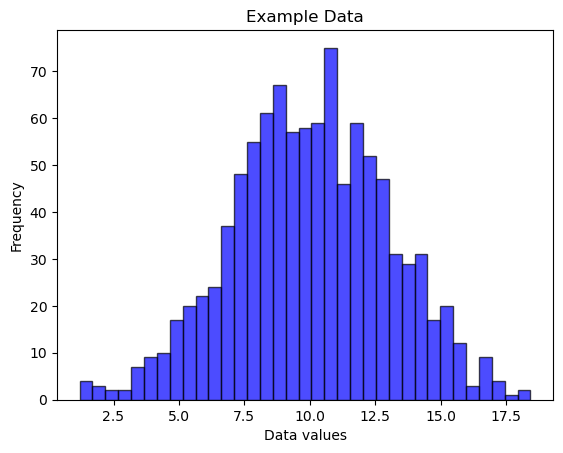

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

pop = np.random.normal(10, 3, 30000) # Mean 10 and variance 3. Sample size 30000. 
obs = pop[np.random.randint(1, 30001, size = 1000)]
mu_obs = np.mean(obs)
plt.hist(obs, bins = 35, color = 'blue', edgecolor = 'black', alpha = 0.7)
plt.xlabel('Data values')
plt.ylabel('Frequency')
plt.title('Example Data')
plt.show()

As a transition rule (the $r$ function), we set the tule $\sigma \leftarrow  N(\sigma, 0.5^2)$. But we need to change $\theta = (\mu, \sigma)$. We keep $\mu$ the same. The symmetry condition required is satisfied. 

In [3]:
def trans(theta):
    return [theta[0], abs(np.random.normal(theta[1], 0.5))]

In [5]:
def like (theta, data):
    return np.sum(-np.log(theta[1]*np.sqrt(2*np.pi)) - ((data - theta[0])**2)/(2*theta[1]**2))

def accept(x, y):
    return np.random.uniform(0, 1) < np.exp(y - x)

def metropolis_hastings(theta, data):
    theta_new = trans(theta)
    H_old = like(theta, data)
    H_new = like(theta_new, data)
    return {'theta': theta_new, 'old': H_old, 'new': H_new}

We now build the markov chain. 

In [13]:
def MCMC(proc, theta_init, iters, data):
    theta = theta_init
    output = []
    accept_reject = []
    for i in range(1, iters + 1):
        res = proc(theta, data)
        if accept(res['old'], res['new']):
            theta = res['theta']
            accept_reject.append(1)
        else:
            accept_reject.append(0)
        output.append(theta)
    return {'output': np.array(output), 'accept_reject': np.array(accept_reject)}



Let us now look at the results. 

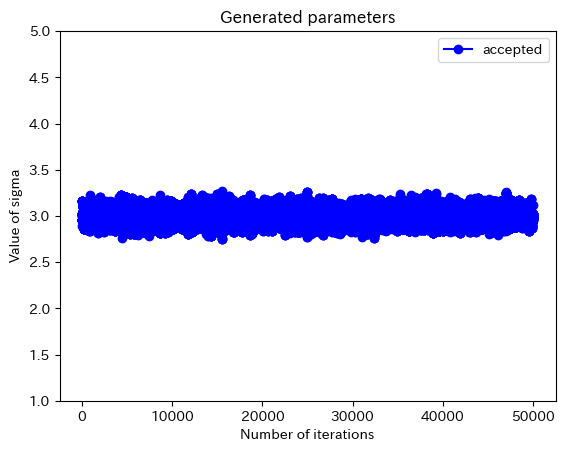

In [14]:
import japanize_matplotlib
m = 50000
result = MCMC(metropolis_hastings, [mu_obs, 3], m, obs)
output = result['output']
output2 = output[:, 1]
colors = 2 * result['accept_reject'] + 2
iterations = range(1, m+1) 
plt.plot(iterations[:len(output2)], output2, color = 'blue', marker='o')
plt.xlabel('Number of iterations')
plt.ylabel('Value of sigma') 
plt.ylim(1.0, 5.0) 
plt.title('Generated parameters') 
plt.legend(['accepted', 'rejected']) 
plt.show()

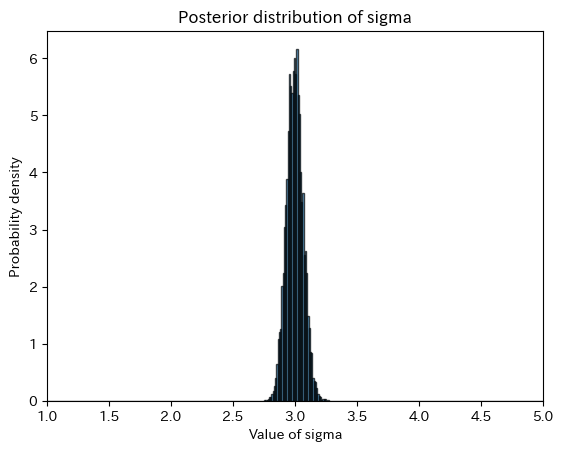

In [17]:
plt.hist(output2 , bins=np.append(np.arange(0, 5, 0.01), 5), edgecolor='black', alpha=0.7, density = True)
plt.xlim(1, 5)
plt.xlabel('Value of sigma') 
plt.ylabel('Probability density') 
plt.title('Posterior distribution of sigma') 
plt.show()